# House Price Prediction Analysis
### Course: CS411 - Artificial Intelligence
### Team: Cameron Barney, Hamza, Marcos Garcia-Leon
### Date of Submission: April 24, 2026

## Project Overview

This project explores the application of classical machine learning to predict housing prices based on various property features. Our primary objective is to develop a model that is both accurate and reliable in estimating house values, while demonstrating the skills and knowledge learned throughout the semester.

## Project Libraries

In [916]:
# Core libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pycaret.regression import *

# Train/Validation/Test split and Preprocessing tools
from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Regression Models
from sklearn.ensemble import RandomForestRegressor, ExtraTreesRegressor, GradientBoostingRegressor, HistGradientBoostingRegressor
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.tree import DecisionTreeRegressor

# Model evaluation metrics
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error, make_scorer
from sklearn.inspection import permutation_importance
from sklearn.model_selection import KFold, cross_validate

# Display settings for easier notebook readability
pd.set_option('display.max_columns', None)  # Show all columns when displaying DataFrames
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)
pd.set_option('display.expand_frame_repr', False)

----------------------------------------------------------------------------------------------------

## Data Overview/Implementation

### Load the datasets

In [917]:
# Load in the simple and complex datasets
simple_df = pd.read_csv("data/SimpleHouse.csv")
complex_df = pd.read_csv("data/ComplexHouse.csv")

### Complex dataset split (Pre-processing & Untouched)

In [918]:
# Preserve original dataset for reference
complex_raw = complex_df.copy()

complex_rawdata = complex_raw.copy()  # raw/minimal processing
complex_cleaned = complex_raw.copy()  # will undergo preprocessing

### Simple & Complex dataset metrics

**This is done prior to pre-processing as a basis**

In [919]:
# Simple Dataset Metrics
print("\nSimple Dataset Info:")
print("Instances:", simple_df.shape[0])
print("Features:", simple_df.shape[1])
print("Columns:", list(simple_df.columns))

# Complex Dataset Metrics
print("\nComplex Dataset Info:")
print("Instances:", complex_df.shape[0])
print("Features:", complex_df.shape[1])
print("Columns:", list(complex_df.columns))


Simple Dataset Info:
Instances: 1471301
Features: 12
Columns: ['brokered_by', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'house_size', 'price_per_sqft', 'price_per_acre', 'area_type']

Complex Dataset Info:
Instances: 81747
Features: 96
Columns: ['Unnamed: 0', 'Id', 'PropertyLocationStreet1', 'PropertyLocationStreet2', 'PropertyCity', 'CountyFIPS', 'PropertyZip', 'OwnerName', 'OwnerMailAddress1', 'OwnerMailAddress2', 'OwnerCity', 'OwnerState', 'OwnerZip', 'CitizensTerritory', 'ConstructionType', 'NumberOfStories', 'NumberOfFamilies', 'YearBuilt', 'YearofRoof', 'YearofRoofVerified', 'RoofMaterial', 'AdjSquareFeet', 'Occupancy', 'NumberOfMonthsUnoccupied', 'PPC', 'BCEG', 'TypeOfResidence', 'FloorOfResidence', 'FloridaWindpool', 'DistancetoCoast', 'DistancetoSinkhole', 'DistancetoHydrant', 'DistancetoFireDepartment', 'FireDistrict', 'RespondingFireDepartment', 'CentralStationAlarm', 'AutomaticSprinklers', 'NumberOfClaims', 'LocationWindSpeed', 'DesignWindSpeed', 'Inte

### Explaining our datasets

Our decision to use two different datasets for this assignment is based on feedback from our Mid-Point presentation.

Our Simple Dataset is a Kaggle dataset based on verified real estate data from Redfin & Zillow. This dataset is already well-structured and pre-cleaned, containing only relevant features with no missing values.
    
    # of Instances: 1,471,301 entries
    
    # of Features: 12 columns
    
    Source: https://www.kaggle.com/datasets/yasirumanujith/usa-real-estate-dataset

Our Complex Dataset is a Kaggle dataset compiled from housing-related data collected from various insurance companies. Compared to the simple dataset, it contains significantly more features and introduces challenges with missing values and irrelevant attributes.
    
    # of Instances: 81,747 entries
   
    # of Features: 95 columns (NOTE: The first column is an un-named empty column)
    
    Source: https://www.kaggle.com/datasets/bharatsahu/house-price-prediction-dataset-insurancehub-usa

The Simple dataset requires minimal preprocessing such as sample size adjustments and outlier handling.

The Complex dataset requires substantial preprocessing due to missing data and feature noise. Two versions of the dataset were created.
    
    A cleaned dataset, which undergoes preprocessing for modeling.
    A raw dataset, used for exploratory analysis and feature selection.

----------------------------------------------------------------------------------------------------------------

## Data Preprocessing

### Identify target variable (the price of the house)

In [920]:
# FIX: Adjusts pandas to show large values in a readable format
pd.options.display.float_format = '{:,.0f}'.format

# Basic descriptive statistics for the target
print("Simple Dataset Price Summary:")
print(simple_df["price"].describe())

print("\nComplex Dataset Price Summary:")
print(complex_df["ValueofHome"].describe())

# Identify skew (comparison between Mean & Median)
print("\nSimple Dataset Skew:", simple_df["price"].skew())
print("Complex Dataset Skew:", complex_df["ValueofHome"].skew())

Simple Dataset Price Summary:
count   1,471,301
mean      394,490
std       230,915
min             1
25%       224,900
50%       349,900
75%       525,000
max     1,147,131
Name: price, dtype: float64

Complex Dataset Price Summary:
count       81,736
mean       243,779
std        233,221
min          2,988
25%        129,528
50%        184,440
75%        282,170
max     12,605,931
Name: ValueofHome, dtype: float64

Simple Dataset Skew: 0.8503671429693103
Complex Dataset Skew: 7.9332657669054125


### Identifying issues with "Price"

**Simple Target Analysis:**
- No missing values in the target variable
- Min ($1) --> noticable outlier (no homes are $1)
- Mean ($390,575) > Median ($349,000) --> mild right skew
- Skewness = 0.87 --> moderate skew, typical for house data
- Max ($1.15M) vs 75th percentile ($515K) --> higher end homes exist, but within a reasonable range.
- Standard Deviation = $230,915 --> Use this as basline error to compare later (same kind of error)

**Complex Target Analysis:**
- 11 missing values in the target variable --> requires imputation or removal
- Min ($1) --> far below 25th percentile (possible data inconsistency)
- Mean ($243,779) > Median ($184,440) --> heavy skew 
- Skewness = 7.93 --> Extemely high skew, indicating outliers or inconsistencies with data.
- Max ($12.6M) vs 75th percentile ($282K) --> large variability in home values
- Standard Deviation = $233,221


----------------------------------------------------------------------------------------------------------------

### Remove Irrelevant Features

In [921]:
# Removing features that are unimportant to the target
drop_cols = ['Id', 
             'PropertyLocationStreet1',
             'PropertyLocationStreet2',
             'CountyFIPS',
             'PropertyZip',
             'OwnerName',
             'OwnerMailAddress1',
             'OwnerMailAddress2',
             'OwnerCity',
             'OwnerState',
             'OwnerZip',
             'CitizensTerritory',
             'NumberOfFamilies',
             'YearofRoof',
             'PPC',
             'BCEG',
             'FloorOfResidence',
             'FloridaWindpool',
             'DistancetoSinkhole',
             'DistancetoHydrant',
             'FireDistrict',
             'RespondingFireDepartment',
             'LocationWindSpeed',
             'WindborneDebrisRegion',
             'Terrain',
             'DesignExposure',
             'Vacant',
             'FloodZone',
             'ConstructedOverWater',
             'ImprovementQualityDate',
             'PoliceID',
             'FireID',
             'CountyName',
             'CentroidLatitude',
             'CentroidLongitude',
             'CoastLatitude',
             'CoastLongitude',
             'FireStationLatitude',
             'FireStationLongitude',
             'SinkholeLatitude',
             'SinkholeLongitude',
             'SinkholeId',
             'SinkholeAddress',
             'NumberOfBusiness',
             'HydrantLatitude',
             'HydrantLongitude',
             'LastSalePrice',
             'LastSaleDate',
             'FloodzoneLastUpdatedDate',
             'StateParcelId',
             'AssesmentYear',
             'Unnamed: 0',
             'UnattachedStructure',
             'TTTerritory']

# Show all columns (prior to removal)
print("Columns before cleaning", complex_df.shape[1])

# Identifying columns that have no values 
all_missing_cols = complex_cleaned.columns[complex_cleaned.isnull().all()]
print("Number of columns with missing values", len(all_missing_cols))

# Dropping the irrelevant & missing features
complex_cleaned.drop(columns=all_missing_cols, inplace=True)
complex_cleaned.drop(columns=drop_cols, inplace=True, errors='ignore')

# Show all columns (after cleaning)
print("Columns after cleaning:", complex_cleaned.shape[1])
print("Columns: ", complex_cleaned.columns.tolist())

Columns before cleaning 96
Number of columns with missing values 21
Columns after cleaning: 21
Columns:  ['PropertyCity', 'ConstructionType', 'NumberOfStories', 'YearBuilt', 'YearofRoofVerified', 'RoofMaterial', 'AdjSquareFeet', 'TypeOfResidence', 'DistancetoCoast', 'DistancetoFireDepartment', 'RoofShape', 'ValueofHome', 'FarmsNRanches', 'Pool', 'ParcelSize', 'ImprovementQuality', 'NumberOfBuildings', 'NumberOfUnits', 'PropertyState', 'EffectiveYearBuilt', 'Homestead']


### Irrelevant Feature Analysis
Most of the features we removed fell into clear unimportant groups

    Identifiers: 'Id', 'FireID', 'StateParceID'

    Owner Info: 'OwnerName', 'OwnerMailAddress1', 'OwnerZip'

    Exact Coordinates: any 'Latitude' or 'Longitude' features

    Potential Leaks: 'LastSalePrice' & 'LastSaleDate'

There are some potenially important features that we will check for later

    'NumberOfFamilies' --> multi-family homes may influence cost

    'Terrain', 'FloodZone', 'WindSpeed' --> environmental factors


### Remove Data Leakage Features

During model training, we discovered that there were some features that were causing data leakages. 

In our Simple Dataset, the features "price_per_sqft" & "price_per_acre" were giving the models the answer, resulting in a R-squared score of 1 (unrealistic)

In [922]:
print("Before removal:")
print(simple_df.columns.tolist())
print("Total columns:", len(simple_df.columns))

# FIX: ISSUE WITH DATA LEAKAGE 
# "price_per_sqft" & "price_per_acre" are causing a data leak --> giving the models the answer
# This is resulting in R-squared values of 1 (which is not realistic)

leakage_cols = ["price_per_sqft", "price_per_acre"]

simple_df = simple_df.drop(columns=leakage_cols)

print("\nAfter removal:")
print(simple_df.columns.tolist())
print("Total columns:", len(simple_df.columns))

Before removal:
['brokered_by', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'house_size', 'price_per_sqft', 'price_per_acre', 'area_type']
Total columns: 12

After removal:
['brokered_by', 'price', 'bed', 'bath', 'acre_lot', 'street', 'city', 'state', 'house_size', 'area_type']
Total columns: 10


### Adjust Problematic Features

**Complex Clean - "ParcelSize"**

In [923]:
upper = complex_cleaned["ParcelSize"].quantile(0.99)

complex_cleaned["ParcelSize"] = complex_cleaned["ParcelSize"].clip(upper=upper)

The "ParcelSize" feature contains extreme values that can greatly influence model training in a negative way.

The approach of "clipping" limits abnormally large features without removing the data points. Any value above the 99th percentile is replaced with the threshold value.

----------------------------------------------------------------------------------------------------------------

### Removing rows with Missing "price"

In [924]:
# Removing rows with missing values in target feature
simple_df = simple_df.dropna(subset=["price"])
complex_cleaned = complex_cleaned.dropna(subset=["ValueofHome"])
complex_raw = complex_raw.dropna(subset=["ValueofHome"])

# Verify removal
print("Simple missing target:", simple_df["price"].isnull().sum())
print("Clean complex missing target:", complex_cleaned["ValueofHome"].isnull().sum())
print("Raw complex missing target:", complex_raw["ValueofHome"].isnull().sum())

Simple missing target: 0
Clean complex missing target: 0
Raw complex missing target: 0


We want to make sure that any instances that are missing the target feature are removed.

The reason we remove these instances rather than impute them is because it would introduce artificial data into the predicted feature.

----------------------------------------------------------------------------------------------------------------

### Randomize & Sample the datasets

Before our train/test split, we want to randomize and get a sample size of our datasets.

In [925]:
# Shuffle both datasets
simple_shuffled = simple_df.sample(frac=1, random_state=42).reset_index(drop=True)
complex_clean_shuffled = complex_cleaned.sample(frac=1, random_state=42).reset_index(drop=True)
complex_raw_shuffled = complex_rawdata.sample(frac=1, random_state=42).reset_index(drop=True)

# (frac=1)                      - Shuffles everything
# random_state=42               - make it reproducible
# reset_index(drop=True)        - cleans up row numbering

Randomization is done to avoid any ordering bias that exists (Cities & States are grouped together).

In [926]:
# Sample sizes
simple_sample_size = int(len(simple_df) * 0.10)             # Starting with 10% of the full dataset as a sample size (~140,000 instancs)
complex_clean_sample_size = len(complex_cleaned)            # Small enough dataset --> keep the full dataset
complex_raw_sample_size = len(complex_rawdata)

# Create samples
simple_sample = simple_shuffled.sample(n=simple_sample_size, random_state=42).reset_index(drop=True)
complex_c_sample = complex_clean_shuffled.sample(n=complex_clean_sample_size, random_state=42).reset_index(drop=True)
complex_r_sample = complex_raw_shuffled.sample(n=complex_raw_sample_size, random_state=42).reset_index(drop=True)

A sample size is chosen for the simple dataset due to the large number of instances.

The complex dataset does not need a sample size, as the number of instances is lower and the data is messy. We do not want to lose too much data.

In [927]:
# Check results
print("Simple Sample Shape:", simple_sample.shape)
print("Cleaned Complex Sample Shape:", complex_c_sample.shape)
print("Raw Complex Sample Shape:", complex_r_sample.shape)

Simple Sample Shape: (147130, 10)
Cleaned Complex Sample Shape: (81736, 21)
Raw Complex Sample Shape: (81747, 96)


----------------------------------------------------------------------------------------------------------------

### Separate the Target Feature

In [928]:
# Rename the target column in Complex (ValueOfHome --> Price)
complex_c_sample = complex_c_sample.rename(columns={"ValueofHome":"price"})
complex_r_sample = complex_r_sample.rename(columns={"ValueofHome":"price"})

In [929]:
# Splitting target from datasets and places them in 'y'
def split_features_target(df, target_col="price"):
    X = df.drop(target_col, axis=1)
    y = df[target_col]
    return X, y

X_simple, y_simple = split_features_target(simple_sample)
X_complex_clean, y_complex_clean = split_features_target(complex_c_sample)
X_complex_raw, y_complex_raw = split_features_target(complex_r_sample)

# Sanity Check (expecting X shape: XX columns | expecting y shape: {no columns})
print("Simple X shape:", X_simple.shape)
print("Simple y shape:", y_simple.shape)

print("\nComplex clean X shape:", X_complex_clean.shape)
print("Complex clean y shape:", y_complex_clean.shape)

print("\nComplex raw X shape:", X_complex_raw.shape)
print("Complex raw y shape:", y_complex_raw.shape)

Simple X shape: (147130, 9)
Simple y shape: (147130,)

Complex clean X shape: (81736, 20)
Complex clean y shape: (81736,)

Complex raw X shape: (81747, 95)
Complex raw y shape: (81747,)


----------------------------------------------------------------------------------------------------------------

### Training, Validation, & Testing Split

**Standard split ratio: 70% --> Training | 15% --> Validation | 15% --> Testing**

In [930]:
from sklearn.model_selection import train_test_split

# Simple Dataset - Split --> Training + Temp
X_train_s, X_temp_s, y_train_s, y_temp_s = train_test_split(
    X_simple,
    y_simple,
    test_size=0.30,
    random_state=42
)

# Complex Clean Dataset - Split --> Training + Temp
X_train_cc, X_temp_cc, y_train_cc, y_temp_cc = train_test_split(
    X_complex_clean,
    y_complex_clean,
    test_size=0.30,
    random_state=42
)   

# Complex Raw Dataset - Split --> Training + Temp
X_train_cr, X_temp_cr, y_train_cr, y_temp_cr = train_test_split(
    X_complex_raw,
    y_complex_raw,
    test_size=0.30,
    random_state=42
)   

In [931]:
# Simple Dataset - Temp --> Validation + Test
X_val_s, X_test_s, y_val_s, y_test_s = train_test_split(
    X_temp_s,
    y_temp_s,
    test_size=0.5,
    random_state=42
)

# Complex Clean Dataset - Temp --> Validation + Test
X_val_cc, X_test_cc, y_val_cc, y_test_cc = train_test_split(
    X_temp_cc,
    y_temp_cc,
    test_size=0.5,
    random_state=42
)

# Complex Raw Dataset - Temp --> Validation + Test
X_val_cr, X_test_cr, y_val_cr, y_test_cr = train_test_split(
    X_temp_cr,
    y_temp_cr,
    test_size=0.5,
    random_state=42
)

In [932]:
# Verify Shapes
print("Simple Dataset:", X_simple.shape[0], " instances")
print("Train (70%):", X_train_s.shape)
print("Validation (15%):", X_val_s.shape)
print("Test (15%):", X_test_s.shape)

print("\nClean Complex Dataset:", X_complex_clean.shape[0], " instances")
print("Train (70%):", X_train_cc.shape)
print("Validation (15%):", X_val_cc.shape)
print("Test (15%):", X_test_cc.shape)

print("\nRaw Complex Dataset:", X_complex_raw.shape[0], " instances")
print("Train (70%):", X_train_cr.shape)
print("Validation (15%):", X_val_cr.shape)
print("Test (15%):", X_test_cr.shape)

Simple Dataset: 147130  instances
Train (70%): (102991, 9)
Validation (15%): (22069, 9)
Test (15%): (22070, 9)

Clean Complex Dataset: 81736  instances
Train (70%): (57215, 20)
Validation (15%): (12260, 20)
Test (15%): (12261, 20)

Raw Complex Dataset: 81747  instances
Train (70%): (57222, 95)
Validation (15%): (12262, 95)
Test (15%): (12263, 95)


### Analysis of Train/Validation/Test Split

Our sampled datasets were divided into training (70%), validation (15%), and test (15%) subsets to evaluate the model's performance.

The training set is the foundation of the model, allowing our models to learn patterns and relationships between features and the house price. Training is the largest subset in order to maximize the model's ability to make predictions.

The validation set is used during model development to tune and optimize the model before using testing. Unlike the training set, it is not used to update model weights directly. Rather, the validation set provides an unbiased estimate of the model's performance during development.

The testing set is a completely independent subset used to evaluate the final model's performance after all training and tuning is complete. It simulates how the model will perform on unseen data.

----------------------------------------------------------------------------------------------------------------

### Handling Missing Values

**Imputer for X**

In [933]:
# Imputer for X values (instances)
def impute_data(X_train, X_val, X_test):
    X_train = X_train.copy()
    X_val = X_val.copy()
    X_test = X_test.copy()

    # Replace placeholder values to missing values
    X_train = X_train.replace(-99, np.nan)          # The only placeholder value identified in the datasets was -99
    X_val = X_val.replace(-99, np.nan)
    X_test = X_test.replace(-99, np.nan)

    # Separate numerical & categorical columns
    num_cols = X_train.select_dtypes(include=["int64", "float64", "bool"]).columns.tolist()
    cat_cols = X_train.select_dtypes(include=["object"]).columns.tolist()

    # Numeric / bool columns
    if num_cols:

        # Missing numerical values are filled in with the median
        num_imputer = SimpleImputer(strategy="median", keep_empty_features=True)

        # Apply the imputer to training sets/validation sets/test sets
        X_train_num = pd.DataFrame(
            num_imputer.fit_transform(X_train[num_cols]),
            columns=num_cols,
            index=X_train.index
        )
        X_val_num = pd.DataFrame(
            num_imputer.transform(X_val[num_cols]),     # NOTE: Using tranform over fit.transform to avoid fitting validation data
            columns=num_cols,
            index=X_val.index
        )
        X_test_num = pd.DataFrame(
            num_imputer.transform(X_test[num_cols]),
            columns=num_cols,
            index=X_test.index
        )
    else:
        X_train_num = pd.DataFrame(index=X_train.index)
        X_val_num = pd.DataFrame(index=X_val.index)
        X_test_num = pd.DataFrame(index=X_test.index)

    # Categorical columns
    if cat_cols:

        # Missing categorical values are filled in with the most common values
        cat_imputer = SimpleImputer(strategy="most_frequent", keep_empty_features=True)

        # Apply the imputer to training sets/validation sets/test sets
        X_train_cat = pd.DataFrame(
            cat_imputer.fit_transform(X_train[cat_cols]),
            columns=cat_cols,
            index=X_train.index
        )
        X_val_cat = pd.DataFrame(
            cat_imputer.transform(X_val[cat_cols]),
            columns=cat_cols,
            index=X_val.index
        )
        X_test_cat = pd.DataFrame(
            cat_imputer.transform(X_test[cat_cols]),
            columns=cat_cols,
            index=X_test.index
        )
    else:
        X_train_cat = pd.DataFrame(index=X_train.index)
        X_val_cat = pd.DataFrame(index=X_val.index)
        X_test_cat = pd.DataFrame(index=X_test.index)

    # Combine numerical and categorical columns back together
    X_train_imputed = pd.concat([X_train_num, X_train_cat], axis=1)
    X_val_imputed = pd.concat([X_val_num, X_val_cat], axis=1)
    X_test_imputed = pd.concat([X_test_num, X_test_cat], axis=1)

    # Restore original column order
    X_train_imputed = X_train_imputed[X_train.columns]
    X_val_imputed = X_val_imputed[X_val.columns]
    X_test_imputed = X_test_imputed[X_test.columns]

    return X_train_imputed, X_val_imputed,X_test_imputed

### Imputation Call

In [934]:
X_train_s, X_val_s, X_test_s = impute_data(X_train_s, X_val_s, X_test_s)
X_train_cr, X_val_cr, X_test_cr = impute_data(X_train_cr, X_val_cr, X_test_cr)
X_train_cc, X_val_cc, X_test_cc = impute_data(X_train_cc, X_val_cc, X_val_cc)

### Analysis of Feature Imputation

We decided the easiest way to handle missing values within the feature set (X) was to use a structured imputation process designed to preserve data integrity.

First, placeholder values (e.g. -99) were converted into standard missing values (NaN) to level out the data that the imputer works with. The dataset was then divided into numerical and categorical features, so we could implement the appropriate imputation strategies based on data type.

For numerical columns, missing values were replaced with the median of the training data (corresponding to the appropriate feature)

For categorical columns, missing values were replaced with the most frequent category of the training data (corresponding to the appropriate feature)

All imputation models were fit exclusively on the training data and then applied to the validation and test sets. This prevents any data leakage into Validation & Test, to ensure they do not get influenced by unseen data.

After imputation, the numerical and categorical features are merged back into a single dataset.

----------------------------------------------------------------------------------------------------------------

### Feature Interactions

In [935]:
# Identifying potential feature interactions within the Simple Dataset features
def add_interaction_features(X):
    X = X.copy()

    # Size / layout interactions
    X["bed_bath"] = X["bed"] * X["bath"]

    # Avoid division by zero with +1
    X["sqft_per_bed"] = X["house_size"] / (X["bed"] + 1)
    X["sqft_per_bath"] = X["house_size"] / (X["bath"] + 1)

    # Land-to-house ratio
    X["lot_per_sqft"] = X["acre_lot"] / (X["house_size"] + 1)

    # Density / Living Style (crowded vs spacious homes)
    X["bed_density"] = X["bed"] / (X["acre_lot"] + 1)

    X["sqft_per_room"] = X["house_size"] / (X["bed"] + X["bath"] + 1)

    return X

In [936]:
# Apply the interaction features to the Simple input features
X_train_s = add_interaction_features(X_train_s)
X_val_s = add_interaction_features(X_val_s)
X_test_s = add_interaction_features(X_test_s)

In [937]:
# Identifying potential feature interactions within the Complex Clean Dataset features
def add_interaction_features_cc(X):
    X = X.copy()

    # Total living space relative to land
    X["sqft_per_acre"] = (X["AdjSquareFeet"] / (X["ParcelSize"] + 1))

    # Building density (how packed the property is)
    X["sqft_per_unit"] = (X["AdjSquareFeet"] / (X["NumberOfUnits"] + 1))

    # Property age
    X["property_age"] = 2026 - X["YearBuilt"]

    # Effective age (after renovations)
    X["effective_age"] = 2026 - X["EffectiveYearBuilt"]

    # Roof age
    X["roof_age"] = 2026 - X["YearofRoofVerified"]

    return X

In [938]:
# Apply the interaction features to the Complex Clean input features
X_train_cc = add_interaction_features_cc(X_train_cc)
X_val_cc = add_interaction_features_cc(X_val_cc)
X_test_cc = add_interaction_features_cc(X_test_cc)

### Analysis of Feature Engineering

In order to improve our model's performance, we added additional interaction features for both the Simple and Complex datasets. Interaction features help models capture "non-linear relationships"

The Simple dataset shows one of its main problems here, being the low feature count. It limits how many impactful interactions can be added. The Complex dataset does not have this problem.

----------------------------------------------------------------------------------------------------------------

### Outlier Identification (Training Data only)

**Establish outlier bounds**

In [939]:
# Outlier Identification Function
def identify_outliers(y, dataset_name, lower_per=0.01, upper_per=0.98):
    lower_bound = y.quantile(lower_per)
    upper_bound = y.quantile(upper_per)

    # Boolean mask for outliers
    outliers = (y < lower_bound) | (y > upper_bound)

    # Count how many outliers exist
    num_outliers = outliers.sum()

    # Total number of data points 
    total = len(y)

    # Percentage of dataset considered outliers
    percent = (num_outliers / total) * 100

    # Print summary statistics
    print(f"\n{dataset_name}")
    print(f"Lower Bound ({lower_per*100:.0f}th percentile): {lower_bound:,.0f}")
    print(f"Upper Bound ({upper_per*100:.0f}th percentile): {upper_bound:,.0f}")
    print(f"Outliers: {num_outliers:,} / {total:,} ({percent:.2f}%)")

    # Return values for later use (removal step)
    return lower_bound, upper_bound, outliers

In [940]:
# Identify outliers in the Simple dataset
# Uses only training target values (y_train_s)
s_lower, s_upper, s_outliers = identify_outliers(
    y_train_s, "Simple Dataset"
)

# Identify outliers in the Clean Complex dataset
cc_lower, cc_upper, cc_outliers = identify_outliers(
    y_train_cc, "Clean Complex Dataset"
)

# Identify outliers in the Raw Complex dataset
cr_lower, cr_upper, cr_outliers = identify_outliers(
    y_train_cr, "Raw Complex Dataset"
)

# Store original sizes for later verification
# Simple
orig_train_s = len(y_train_s)

# Clean Complex
orig_train_cc = len(y_train_cc)

# Raw Complex
orig_train_cr = len(y_train_cr)


Simple Dataset
Lower Bound (1th percentile): 44,994
Upper Bound (98th percentile): 980,000
Outliers: 3,083 / 102,991 (2.99%)

Clean Complex Dataset
Lower Bound (1th percentile): 41,366
Upper Bound (98th percentile): 858,097
Outliers: 1,718 / 57,215 (3.00%)

Raw Complex Dataset
Lower Bound (1th percentile): 41,656
Upper Bound (98th percentile): 857,812
Outliers: 1,718 / 57,222 (3.00%)


**Lower Percentile (1%) - The price below which only 1% of houses fall**

**Upper Percentile (98%) - The price above which only 2% of houses fall**

In [941]:
def inspect_outlier_values(y, outlier_mask, lower_bound, upper_bound, dataset_name, bins, n=5):

    # Extract outlier values
    outlier_values = y[outlier_mask]

    # Histogram Graph
    plt.figure(figsize=(10, 5))

    # Plot all data
    plt.hist(
        y, 
        bins=bins, 
        alpha=0.6, 
        label="All Data")

    # Overlay outliers
    plt.hist(outlier_values, bins=bins, alpha=0.8, label="Outliers")

    # Draw vertical lines for bounds
    plt.axvline(lower_bound, linestyle="--", label="Lower Bound (1%)")
    plt.axvline(upper_bound, linestyle="--", label="Upper Bound (98%)")

    # Scale the graph to better align with instance count
    plt.xlim(0, 1500000)

    plt.title(f"{dataset_name} - Outlier Identification (Histogram)")
    plt.xlabel("Price")
    plt.ylabel("Frequency")
    plt.legend()
    plt.show()

    # Text Output
    print(f"\n--- {dataset_name} ---")

    print(f"Lower Bound (1st percentile): {lower_bound:,.0f}")
    print(f"Upper Bound (98th percentile): {upper_bound:,.0f}")

    print(f"\nTop {n} highest outliers:")
    print(outlier_values.sort_values(ascending=False).head(n))

    print(f"\nBottom {n} lowest outliers:")
    print(outlier_values.sort_values().head(n))

    print(f"\nTotal outliers identified: {len(outlier_values):,}")
    print("-" * 50)

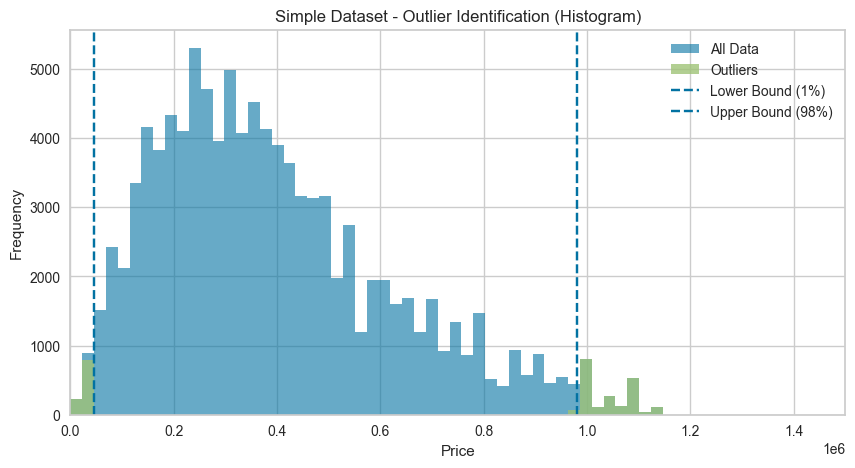


--- Simple Dataset ---
Lower Bound (1st percentile): 44,994
Upper Bound (98th percentile): 980,000

Top 5 highest outliers:
7407     1,147,000
22047    1,146,488
38313    1,145,000
10594    1,145,000
145388   1,145,000
Name: price, dtype: float64

Bottom 5 lowest outliers:
133900   1
74408    1
70737    1
60127    1
7835     1
Name: price, dtype: float64

Total outliers identified: 3,083
--------------------------------------------------


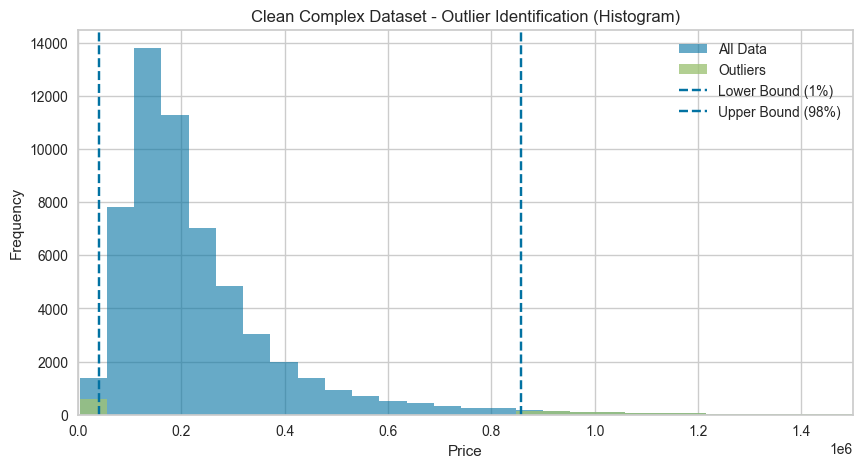


--- Clean Complex Dataset ---
Lower Bound (1st percentile): 41,366
Upper Bound (98th percentile): 858,097

Top 5 highest outliers:
57664   12,605,931
52037    6,493,755
13344    6,239,490
61507    5,978,678
55651    5,371,854
Name: price, dtype: float64

Bottom 5 lowest outliers:
69043   3,069
34785   3,338
29900   3,338
38278   4,900
22903   5,564
Name: price, dtype: float64

Total outliers identified: 1,718
--------------------------------------------------


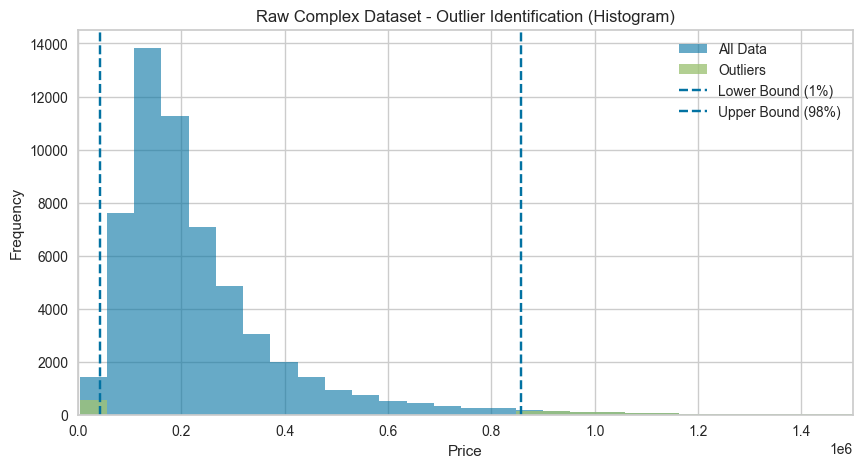


--- Raw Complex Dataset ---
Lower Bound (1st percentile): 41,656
Upper Bound (98th percentile): 857,812

Top 5 highest outliers:
63161   12,605,931
63824    6,493,755
63654    6,353,735
76211    6,273,358
80627    6,239,490
Name: price, dtype: float64

Bottom 5 lowest outliers:
62738   3,069
15921   3,338
1645    3,672
74932   4,900
19930   5,500
Name: price, dtype: float64

Total outliers identified: 1,718
--------------------------------------------------


In [942]:
bins_s = int(len(y_train_s) ** 0.5)
bins_cc = int(len(y_train_cc) ** 0.5)
bins_cr = int(len(y_train_cr) ** 0.5)

inspect_outlier_values(y_train_s, s_outliers, s_lower, s_upper, "Simple Dataset", 50)
inspect_outlier_values(y_train_cc, cc_outliers, cc_lower, cc_upper, "Clean Complex Dataset", bins_cc)
inspect_outlier_values(y_train_cr, cr_outliers, cr_lower, cr_upper, "Raw Complex Dataset", bins_cr)

### Simple Dataset Outlier Analysis

Lower Percentile (1%) - $44,994 | Upper Percentile (98%) - $980,000

Simple Dataset: 3,083 outliers out of 102,991 instances (within training) - 3% outliers in training

- Most homes are clustered between ~$100k - $500k
- Long tail to the right --> fewer more expensive homes (98th percentile was chosen to help remove higher-end outliers)
- ~$45k - USEABLE DATA - ~$980k

### Complex (Clean & Raw) Dataset Outlier Analysis

Lower Percentile (1%) - ($41,366 | $41,656) | Upper Percentile (99%) - ($858,097 | $857,812) 

Complex Clean Dataset: 1,718 outliers out of 57,215 instances (within training)     - 3%

Complex Raw Dataset: 1,718 outliers out of 57,222 instances (within training)       - 3%


- Most homes are clustered between ~$100k - $300k
- Long tail to the right --> fewer more expensive homes
- ~$40k - USEABLE DATA - ~$850k

### Outlier Removal

In [943]:
def remove_outliers(X, y, lower_bound, upper_bound):
    # Make sure X and y use the same index
    X = X.copy()
    y = y.copy()

    X = X.reset_index(drop=True)
    y = y.reset_index(drop=True)

    # Build mask from target variable
    mask = (y >= lower_bound) & (y <= upper_bound)

    # Apply mask
    X_filtered = X.loc[mask].reset_index(drop=True)
    y_filtered = y.loc[mask].reset_index(drop=True)

    return X_filtered, y_filtered, mask

In [944]:
# Sample Dataset Outlier Removal
X_train_s, y_train_s, s_mask = remove_outliers(
    X_train_s, y_train_s, s_lower, s_upper
)

X_val_s, y_val_s, _ = remove_outliers(
    X_val_s, y_val_s, s_lower, s_upper
)

X_test_s, y_test_s, _ = remove_outliers(
    X_test_s, y_test_s, s_lower, s_upper
)

# Complex Clean Dataset Outlier Removal
X_train_cc, y_train_cc, cc_mask = remove_outliers(
    X_train_cc, y_train_cc, cc_lower, cc_upper
)

X_val_cc, y_val_cc, _ = remove_outliers(
    X_val_cc, y_val_cc, cc_lower, cc_upper
)

X_test_cc, y_test_cc, _ = remove_outliers(
    X_test_cc, y_test_cc, cc_lower, cc_upper
)

# Complex Raw Dataset Outlier Removal
X_train_cr, y_train_cr, cr_mask = remove_outliers(
    X_train_cr, y_train_cr, cr_lower, cr_upper
)

X_val_cr, y_val_cr, _ = remove_outliers(
    X_val_cr, y_val_cr, cr_lower, cr_upper
)

X_test_cr, y_test_cr, _ = remove_outliers(
    X_test_cr, y_test_cr, cr_lower, cr_upper
)

In [945]:
# Verify outlier removal
def print_outlier_verification(original, new, dataset_name):
    removed = original - new
    percent = (removed / original) * 100

    print(f"\n{dataset_name}")
    print(f"Original Size: {original:,}")
    print(f"New Size: {new:,}")
    print(f"Rows Removed: {removed:,} ({percent:.2f}%)")

In [946]:
print_outlier_verification(orig_train_s, len(y_train_s), "Simple Dataset")
print_outlier_verification(orig_train_cc, len(y_train_cc), "Clean Complex Dataset")
print_outlier_verification(orig_train_cr, len(y_train_cr), "Raw Complex Dataset")


Simple Dataset
Original Size: 102,991
New Size: 99,908
Rows Removed: 3,083 (2.99%)

Clean Complex Dataset
Original Size: 57,215
New Size: 55,497
Rows Removed: 1,718 (3.00%)

Raw Complex Dataset
Original Size: 57,222
New Size: 55,495
Rows Removed: 1,727 (3.02%)


### Outlier Removal Analysis

One major change from our previous build was the identification and removal of outliers. In both datasets, we observed various prices that either do not make sense ($1 houses) or were very clearly not applicable to the average home buying experience ($12.6M houses).

The outlier thresholds of the 1st and 99th percentile were derived from the training data. We decided on these thresholds to eliminate very obvious outliers, but still leave some room for higher end houses to be included.

In all datasets, we noticed ~2% of total training instances were removed. These results confirm that the outlier removal process was applied consistently across all datasets. This step marks the end of our preprocessing work as we start moving to model training.

----------------------------------------------------------------------------------------------------------------

### Final Preprocessing Check

In [947]:
# FIX: COMPLEX CLEAN TEST SPLIT HAS A INDEX MISALIGNMENT
common_index = X_test_cc.index.intersection(y_test_cc.index)

X_test_cc = X_test_cc.loc[common_index]
y_test_cc = y_test_cc.loc[common_index]

X_test_cc = X_test_cc.reset_index(drop=True)
y_test_cc = y_test_cc.reset_index(drop=True)

print(X_test_cc.shape, y_test_cc.shape)
print("Aligned:", X_test_cc.index.equals(y_test_cc.index))

(11915, 25) (11915,)
Aligned: True


In [948]:
def final_preprocessing_check(X_train, y_train, X_val, y_val, X_test, y_test,
                              lower_bound, upper_bound, dataset_name):
    print(f"\n==== {dataset_name} ====")

    # Shape Check
    print("\n[Shape Check]")
    print("Train: ", X_train.shape, "| y: ", y_train.shape)
    print("Validation: ", X_val.shape, "| y: ", y_val.shape)
    print("Test: ", X_test.shape, "| y: ", y_test.shape)

    # Missing Values Check
    print("\n[Missing Values Check]")
    print("Train X missing:", X_train.isnull().sum().sum())
    print("Validation X missing:  ", X_val.isnull().sum().sum())
    print("Test X missing: ", X_test.isnull().sum().sum())

    print("Train y missing:", y_train.isnull().sum())
    print("Validation y missing:  ", y_val.isnull().sum())
    print("Test y missing: ", y_test.isnull().sum())

    # Outlier Check (Using original bounds)
    print("\n[Outlier Check - Using Original Bounds]")
    train_outliers = ((y_train < lower_bound) | (y_train > upper_bound)).sum()
    val_outliers   = ((y_val < lower_bound) | (y_val > upper_bound)).sum()
    test_outliers  = ((y_test < lower_bound) | (y_test > upper_bound)).sum()

    print("Train outliers:", train_outliers)
    print("Validation outliers:  ", val_outliers)
    print("Test outliers: ", test_outliers)

    # Index Alignment Check
    print("\n[Index Alignment Check]")
    print("Train aligned:", X_train.index.equals(y_train.index))
    print("Validation aligned:  ", X_val.index.equals(y_val.index))
    print("Test aligned: ", X_test.index.equals(y_test.index))

    print("\n Preprocessing check complete")
    print("=" * 40)

In [949]:
# Simple Dataset
final_preprocessing_check(
    X_train_s, y_train_s,
    X_val_s, y_val_s,
    X_test_s, y_test_s,
    s_lower, s_upper,
    "Simple Dataset"
)

# Clean Complex Dataset
final_preprocessing_check(
    X_train_cc, y_train_cc,
    X_val_cc, y_val_cc,
    X_test_cc, y_test_cc,
    cc_lower, cc_upper,
    "Clean Complex Dataset"
)

# Raw Complex Dataset
final_preprocessing_check(
    X_train_cr, y_train_cr,
    X_val_cr, y_val_cr,
    X_test_cr, y_test_cr,
    cr_lower, cr_upper,
    "Raw Complex Dataset"
)


==== Simple Dataset ====

[Shape Check]
Train:  (99908, 15) | y:  (99908,)
Validation:  (21421, 15) | y:  (21421,)
Test:  (21409, 15) | y:  (21409,)

[Missing Values Check]
Train X missing: 0
Validation X missing:   0
Test X missing:  0
Train y missing: 0
Validation y missing:   0
Test y missing:  0

[Outlier Check - Using Original Bounds]
Train outliers: 0
Validation outliers:   0
Test outliers:  0

[Index Alignment Check]
Train aligned: True
Validation aligned:   True
Test aligned:  True

 Preprocessing check complete

==== Clean Complex Dataset ====

[Shape Check]
Train:  (55497, 25) | y:  (55497,)
Validation:  (11912, 25) | y:  (11912,)
Test:  (11915, 25) | y:  (11915,)

[Missing Values Check]
Train X missing: 0
Validation X missing:   0
Test X missing:  0
Train y missing: 0
Validation y missing:   0
Test y missing:  0

[Outlier Check - Using Original Bounds]
Train outliers: 0
Validation outliers:   0
Test outliers:  0

[Index Alignment Check]
Train aligned: True
Validation aligne

### Preprocessing Final Check Summary

- The target variable (price) was identified and separated from the input features.

- Irrelavant Features have been removed from the complex dataset to reduce noise and dimensionality.

- All three datasets were randomized in order to eliminate ordering bias.

- The Simple dataset was reduced to a 10% sample to improve efficiency, while the complex datasets retained all available instances.

- Missing and placeholder values in feature sets were imputed.

- The datasets were split into a 70/15/15 (Train/Validation/Test) ratio.

- Outliers were identified using the 1st and 99th percentile thresholds derived from the training data and removed consistently across all splits.

- A final validation check confirmed that all datasets had no missing values, no remaining outliers, and maintain proper alignment between features and the target variable.

----------------------------------------------------------------------------------------------------------------

## Dataset Encoding

**Simple Dataset City Encoding**

In [950]:
# Get the top n cities
top_n = 100
top_cities = X_train_s["city"].value_counts().nlargest(top_n).index

# Function to group cities
def group_city(col):
    return col.where(col.isin(top_cities), "Other")

# Apply to all splits
X_train_s["city_grouped"] = group_city(X_train_s["city"])
X_val_s["city_grouped"]   = group_city(X_val_s["city"])
X_test_s["city_grouped"]  = group_city(X_test_s["city"])

In [951]:
# Drop original city column
X_train_s.drop(columns=["city"], inplace=True)
X_val_s.drop(columns=["city"], inplace=True)
X_test_s.drop(columns=["city"], inplace=True)

**Complex Clean Dataset City Encoding**

In [952]:
top_n = 100

top_cities_cc = X_train_cc["PropertyCity"].value_counts().nlargest(top_n).index

def group_city_cc(col):
    return col.where(col.isin(top_cities_cc), "Other")

X_train_cc["city_grouped"] = group_city_cc(X_train_cc["PropertyCity"])
X_val_cc["city_grouped"]   = group_city_cc(X_val_cc["PropertyCity"])
X_test_cc["city_grouped"]  = group_city_cc(X_test_cc["PropertyCity"])


In [953]:
# Drop original PropertyCity column
X_train_cc = X_train_cc.drop(columns=["PropertyCity"])
X_val_cc   = X_val_cc.drop(columns=["PropertyCity"])
X_test_cc  = X_test_cc.drop(columns=["PropertyCity"])

**Simple Dataset Encoding**

In [954]:
X_train_s_enc = pd.get_dummies(X_train_s, drop_first=False)
X_val_s_enc   = pd.get_dummies(X_val_s, drop_first=False)
X_test_s_enc  = pd.get_dummies(X_test_s, drop_first=False)

# Align validation and test to training columns
X_val_s_enc = X_val_s_enc.reindex(columns=X_train_s_enc.columns, fill_value=0)
X_test_s_enc = X_test_s_enc.reindex(columns=X_train_s_enc.columns, fill_value=0)

print("Train shape:", X_train_s_enc.shape)
print("Val shape:", X_val_s_enc.shape)
print("Test shape:", X_test_s_enc.shape)

print((X_train_s_enc.columns == X_val_s_enc.columns).all())
print((X_train_s_enc.columns == X_test_s_enc.columns).all())

Train shape: (99908, 170)
Val shape: (21421, 170)
Test shape: (21409, 170)
True
True


**Complex Clean Dataset Encoding**

In [955]:
# One-hot encoding
X_train_cc_enc = pd.get_dummies(X_train_cc, drop_first=False)
X_val_cc_enc   = pd.get_dummies(X_val_cc, drop_first=False)
X_test_cc_enc  = pd.get_dummies(X_test_cc, drop_first=False)

# Align validation to training
X_val_cc_enc = X_val_cc_enc.reindex(columns=X_train_cc_enc.columns, fill_value=0)

# Align test to training
X_test_cc_enc = X_test_cc_enc.reindex(columns=X_train_cc_enc.columns, fill_value=0)

print("Train shape:", X_train_cc_enc.shape)
print("Val shape:", X_val_cc_enc.shape)
print("Test shape:", X_test_cc_enc.shape)

print((X_train_cc_enc.columns == X_val_cc_enc.columns).all())
print((X_train_cc_enc.columns == X_test_cc_enc.columns).all())

Train shape: (55497, 164)
Val shape: (11912, 164)
Test shape: (11915, 164)
True
True


### Encoding Analysis

Categorical features were converted into numeric form using one-hot encoding. Necessary for regression.

City variables = High Cardinality variables (contain a large number of unique values)

    One-hot encoding creates a new column for each unique city. With hundreds & thousands of columns being made, it can increase memory usage, slow model training, and increase the risk of overfitting

    To handle this issue, we take the top 100 cities from the training set and preserve them.

    This grouping are later applied to the validation and test sets.

----------------------------------------------------------------------------------------------------------------

## AutoML Implementation

AutoML was incorporated into this project to assist in the model selection process. Our original three models (Linear Regression, Gradient Boosting, and Random Forest) were selected based on preliminary research done early in the project's life.

Initially we were looking at LazyPredict for AutoML, however we ran into quite a few issues while trying to run LazyPredict
- The main issue was the long run times (average runtime = ~ 20 - 30 minutes per test)
- Another issue we encountered was regarding the r-squared values being unrealistic (only outputting 0 or 1)

As an alternative, we created an AutoML simulation using only a few notable models that we found during research. Given more time, we'd like to work on getting proper AutoML implementation.

In [956]:
# Controlled AutoML Simulation

# models = {
#     "Linear Regression": LinearRegression(),
#     "Ridge Regression": Ridge(),
#     "Lasso Regression": Lasso(),
#     "Decision Tree": DecisionTreeRegressor(random_state=42),
#     "Random Forest": RandomForestRegressor(random_state=42, n_estimators=100, n_jobs=1),
#     "Extra Trees": ExtraTreesRegressor(random_state=42, n_estimators=100, n_jobs=1),
#     "Gradient Boosting": GradientBoostingRegressor(random_state=42),
#     "Hist Gradient Boosting": HistGradientBoostingRegressor(random_state=42)
# }

# # ---------------------------
# # Pre-model validation checks
# # ---------------------------
# assert X_train_s_enc.shape[0] == y_train_s.shape[0], "Train X and y row counts do not match"
# assert X_val_s_enc.shape[0] == y_val_s.shape[0], "Validation X and y row counts do not match"
# assert list(X_train_s_enc.columns) == list(X_val_s_enc.columns), "Train and validation columns do not match"

# assert X_train_s_enc.isnull().sum().sum() == 0, "Missing values found in X_train"
# assert X_val_s_enc.isnull().sum().sum() == 0, "Missing values found in X_val"
# assert y_train_s.isnull().sum() == 0, "Missing values found in y_train"
# assert y_val_s.isnull().sum() == 0, "Missing values found in y_val"

# results = []

# for name, model in models.items():
#     model.fit(X_train_s_enc, y_train_s)
#     preds = model.predict(X_val_s_enc)

#     # Prediction validation check
#     assert len(preds) == len(y_val_s), f"{name}: prediction length does not match y_val"

#     rmse = np.sqrt(mean_squared_error(y_val_s, preds))
#     mae = mean_absolute_error(y_val_s, preds)
#     r2 = r2_score(y_val_s, preds)

#     results.append({
#         "Model": name,
#         "RMSE": rmse,
#         "MAE": mae,
#         "R2": r2
#     })

# results_df = pd.DataFrame(results).sort_values(by="RMSE")

# # Clean display formatting
# results_df.style.format({
#     "RMSE": "{:,.0f}",
#     "MAE": "{:,.0f}",
#     "R2": "{:.4f}"
# })

----------------------------------------------------------------------------------------------------------------

## Model Evaluation

**Helper Function for Metrics**

In [957]:
# Helper Function to output metrics
# y_true = The true house prices | y_pred = The model's predictions
def evaluate_regression_model(model_name, dataset_name, y_true, y_pred):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))      # Root Mean Squared Error = the difference between values predicted by a model and the actual observed values.
    mae = mean_absolute_error(y_true, y_pred)               # Mean Absolute Error = the average magnitude of errors in a set of predictions.
    r2 = r2_score(y_true, y_pred)                           # R-squared = measures how well the model fits to the observed data.

    return pd.DataFrame([{
        "Dataset: ": dataset_name,
        "Model: ": model_name,
        "RMSE: ": rmse,
        "MAE: ": mae,
        "R2: ": r2
    }])

**Helper Function for Actual vs Predicted graph**

In [958]:
def plot_actual_vs_pred(y_true, y_pred, title):
    plt.figure(figsize=(7,5))

    # Apply log transform
    y_true_log = np.log1p(y_true)
    y_pred_log = np.log1p(y_pred)

    # Plot distributions
    plt.hist(y_true_log, bins=50, alpha=0.5, label="Actual")
    plt.hist(y_pred_log, bins=50, alpha=0.5, label="Predicted")

    plt.title(f"{title} (Log Distribution)")
    plt.xlabel("Log Price")
    plt.ylabel("Frequency")
    plt.legend()

    plt.show()

----------------------------------------------------------------------------------------------------------------

## Ridge Regression - Simple | Clean Complex

**Ridge Regression - Simple**

,Dataset:,Model:,RMSE:,MAE:,R2:
0,Simple Dataset,Ridge Regression,162938.209430,110419.416379,0.407899


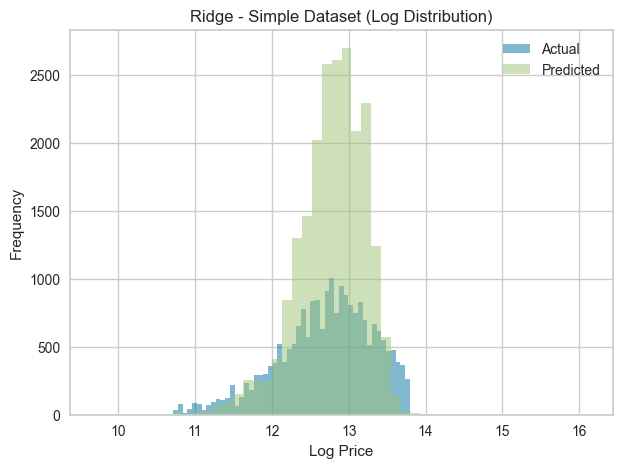

In [959]:
# Define Linear Regression model for Simple
ridge_s = Ridge(alpha=1.0)

ridge_s.fit(X_train_s_enc, y_train_s)

ridge_s_preds = ridge_s.predict(X_val_s_enc)

# Linear Regression results
ridge_s_results = evaluate_regression_model(
    "Ridge Regression",
    "Simple Dataset",
    y_val_s,
    ridge_s_preds
)

display(
    ridge_s_results.style.format({
        "RMSE": "{:,.0f}",
        "MAE": "{:,.0f}",
        "R2": "{:.4f}"
    })
)

plot_actual_vs_pred(y_val_s, ridge_s_preds, "Ridge - Simple Dataset")

RMSE: $162,938

    - Better than baseline (~230k - std) 
    - Predictions are off by ~$163k

MAE: $110,419

    - The typical error is about ~$110k
    - There are still some noticable outliers

R²: 0.41

    - Roughly 41% variance

**Ridge Regression - Complex Clean**

In [960]:
# Scale values
scaler = StandardScaler()

X_train_cc_scaled = scaler.fit_transform(X_train_cc_enc)
X_val_cc_scaled   = scaler.transform(X_val_cc_enc)

,Dataset:,Model:,RMSE:,MAE:,R2:
0,Complex Clean Dataset,Ridge Regression,87144.610997,57668.980629,0.596933


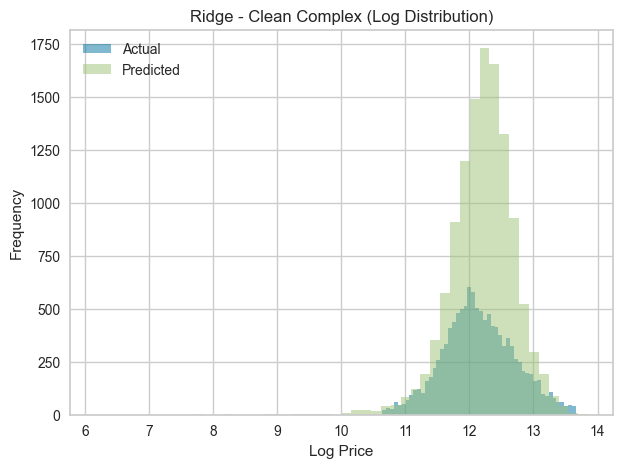

In [961]:
# Define Ridge Regression model for Complex Clean
ridge_cc = Ridge(alpha=1.0)

# Fit the model to our training data
ridge_cc.fit(X_train_cc_scaled, y_train_cc)

# Make predictions based on the validation data
ridge_cc_preds = ridge_cc.predict(X_val_cc_scaled)

# Ridge Regression results
ridge_cc_results = evaluate_regression_model(
    "Ridge Regression",
    "Complex Clean Dataset",
    y_val_cc,
    ridge_cc_preds
)

display(
    ridge_cc_results.style.format({
        "RMSE": "{:,.0f}",
        "MAE": "{:,.0f}",
        "R2": "{:.4f}"
    })
)

plot_actual_vs_pred(y_val_cc, ridge_cc_preds, "Ridge - Clean Complex")

### Ridge Regression Performance

Ridge Regression was used as a baseline model to evaluate how well a linear approach performs on the datatsets.

After observing both results, we came to the conclusion that the linear approach is not effective for our datasets. The model is unable to notice the complex patterns in the data.

We also noticed from the graphs that Ridge Regression tends to remain concentrated towards the mean. This causes the model to underestimate higher-priced homes and overestimate lower-priced homes.

Overall, our baseline model demonstrates the limitations of linear models when applied to skewed, real-world datasets.

----------------------------------------------------------------------------------------------------------------

## Random Forest - Simple | Clean Complex

**Random Forest Model Setup**

In [962]:
rf = RandomForestRegressor(
    n_estimators=200,
    max_depth=15,
    min_samples_leaf=2,
    n_jobs=-1,
    random_state=42
)

**Random Forest - Simple**

,Dataset:,Model:,RMSE:,MAE:,R2:
0,Simple Dataset,Random Forest,143238.890871,107570.882281,0.542415


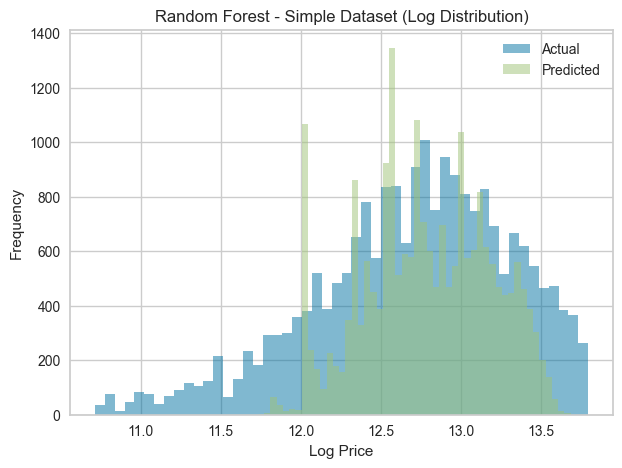

In [963]:
rf_s = rf

rf_s.fit(X_train_s_enc, y_train_s)

rf_s_preds = rf_s.predict(X_val_s_enc)

rf_s_results = evaluate_regression_model(
    "Random Forest",
    "Simple Dataset",
    y_val_s,
    rf_s_preds
)

display(
    rf_s_results.style.format({
        "RMSE": "{:,.0f}",
        "MAE": "{:,.0f}",
        "R2": "{:.4f}"
    })
)

plot_actual_vs_pred(y_val_s, rf_s_preds, "Random Forest - Simple Dataset")

**Random Forest - Complex Clean**

,Dataset:,Model:,RMSE:,MAE:,R2:
0,Clean Complex Dataset,Random Forest,72371.058306,48937.159512,0.722012


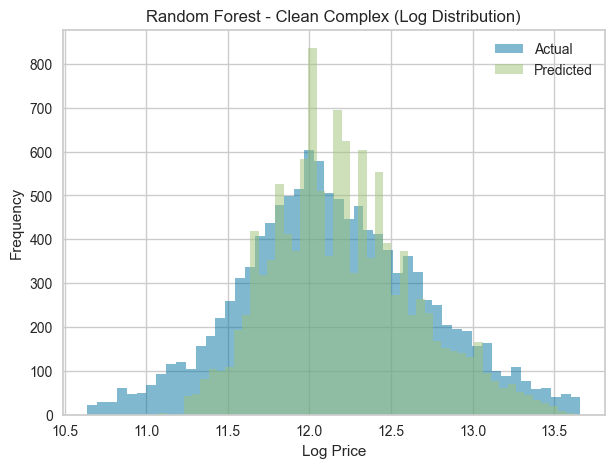

In [971]:
rf_cc = rf

rf_cc.fit(X_train_cc_enc, y_train_cc)

rf_cc_preds = rf_cc.predict(X_val_cc_enc)

rf_cc_results = evaluate_regression_model(
    "Random Forest",
    "Clean Complex Dataset",
    y_val_cc,
    rf_cc_preds
)

display(
    rf_cc_results.style.format({
        "RMSE": "{:,.0f}",
        "MAE": "{:,.0f}",
        "R2": "{:.4f}"
    })
)

plot_actual_vs_pred(y_val_cc, rf_cc_preds, "Random Forest - Clean Complex")

In [975]:
print(rf_cc)
print(y_train_cc.describe())
print((X_train_cc_enc.std() == 0).sum())
print(rf_cc.feature_importances_.sum())

RandomForestRegressor(n_jobs=-1, random_state=42)
count    55,497
mean    223,238
std     140,030
min      41,378
25%     129,800
50%     183,055
75%     275,038
max     858,030
Name: price, dtype: float64
1
1.0


### Random Forest Performance
Random Forest was implemented as a more flexible, non-linear model. Unlike our baseline, Random Forest is capable of capturing complex interactions between features.

After observing the values from Random Forest, we see a clear improvement in both Simple and Complex compared to the Ridge Regression model.

The Random Forest model benefits from a richer feature set, which explains why the Simple dataset has noticably worse results.

Overall, Random Forest provides a strong improvement over the baseline by reducing errors and understanding complex patterns. However, we still see some limitations remain in modeling the full variability of house prices, particularly at the extreme ends.

----------------------------------------------------------------------------------------------------------------

## Hist Gradient Boosting - Simple | Complex Clean

**HistGB Model Setup**

In [965]:
hgb = HistGradientBoostingRegressor(
    max_depth=8,
    learning_rate=0.05,
    max_iter=200,
    random_state=42
)

**HistGB - Simple**

,Dataset:,Model:,RMSE:,MAE:,R2:
0,Simple Dataset,Hist Gradient Boosting,137622.780698,102480.521711,0.577593


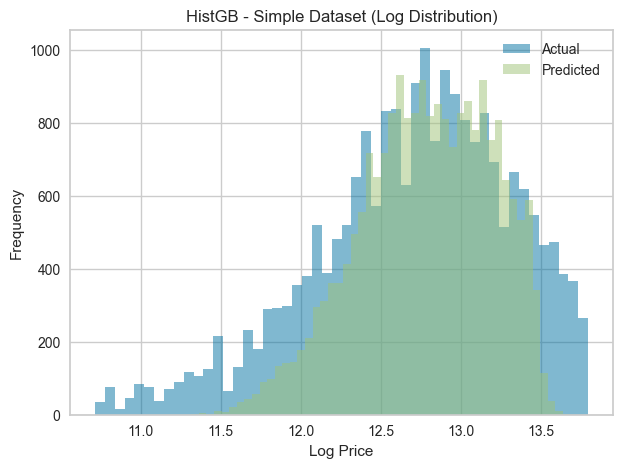

In [966]:
hgb_s = hgb

hgb_s.fit(X_train_s_enc, y_train_s)

hgb_s_preds = hgb_s.predict(X_val_s_enc)

hgb_s_results = evaluate_regression_model(
    "Hist Gradient Boosting",
    "Simple Dataset",
    y_val_s,
    hgb_s_preds
)

display(
    hgb_s_results.style.format({
        "RMSE": "{:,.0f}",
        "MAE": "{:,.0f}",
        "R2": "{:.4f}"
    })
)

plot_actual_vs_pred(y_val_s, hgb_s_preds, "HistGB - Simple Dataset")

**HistGB - Complex Clean**

,Dataset:,Model:,RMSE:,MAE:,R2:
0,Clean Complex Dataset,Hist Gradient Boosting,69917.978451,46367.848271,0.740538


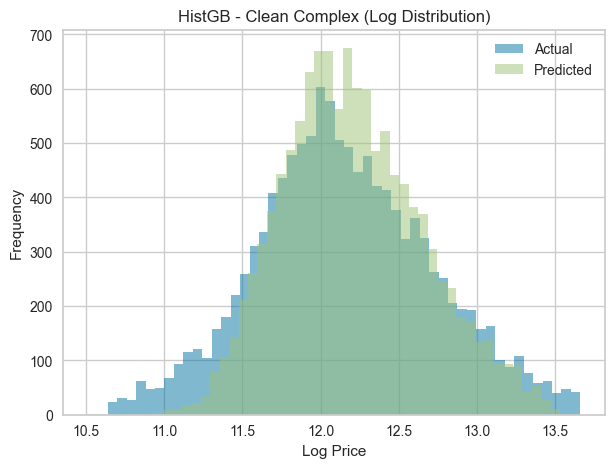

In [967]:
hgb_cc = hgb

hgb_cc.fit(X_train_cc_enc, y_train_cc)

hgb_cc_preds = hgb_cc.predict(X_val_cc_enc)

hgb_cc_results = evaluate_regression_model(
    "Hist Gradient Boosting",
    "Clean Complex Dataset",
    y_val_cc,
    hgb_cc_preds
)

display(
    hgb_cc_results.style.format({
        "RMSE": "{:,.0f}",
        "MAE": "{:,.0f}",
        "R2": "{:.4f}"
    })
)

plot_actual_vs_pred(y_val_cc, hgb_cc_preds, "HistGB - Clean Complex")

### Hist Gradient Boosting Performance

Hist Gradient Boosting was implemented as the final and most advanced model, designed to capture non-linear relationships while improving predictive accuracy over the previous models.

This model provided our best overall model, being HistGB - Complex Clean. It has the lowest RMSE value of all models we tested along with the highest explanatory power achieved among all tests.

Overall, Hist Gradient Boosting provides the most accurate and reliable predictions, leveraging both feature engineering and preprocessing steps.

----------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------

### Feature Importance

**Simple Dataset Feature Importance**

In [979]:
# Ensure the model is built
rf_s = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Fit the model to training data
rf_s.fit(X_train_s_enc, y_train_s)

# Built-in feature importance
rf_importance = pd.DataFrame({
    "Feature": X_train_s_enc.columns,
    "Importance": rf_s.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

display(
    rf_importance.head(15).style.format({
        "Importance": "{:.6f}"
    })
)

,Feature,Importance
2,bath,0.183247
5,house_size,0.106022
16,state_California,0.105055
4,street,0.069656
0,brokered_by,0.069438
7,sqft_per_bed,0.052998
9,lot_per_sqft,0.048748
11,sqft_per_room,0.039905
10,bed_density,0.038273
8,sqft_per_bath,0.032753


**Complex Clean Feature Importance**

In [978]:
# Ensure the model is built
rf_cc = RandomForestRegressor(
    n_estimators=100,
    random_state=42,
    n_jobs=-1
)

# Fit the model to training data
rf_cc.fit(X_train_cc_enc, y_train_cc)

# Built-in feature importance
rf_importance = pd.DataFrame({
    "Feature": X_train_cc_enc.columns,
    "Importance": rf_cc.feature_importances_
})

rf_importance = rf_importance.sort_values(
    by="Importance",
    ascending=False
)

display(
    rf_importance.head(15).style.format({
        "Importance": "{:.6f}"
    })
)

,Feature,Importance
2,AdjSquareFeet,0.336289
3,DistancetoCoast,0.132014
10,sqft_per_unit,0.059707
4,DistancetoFireDepartment,0.039499
5,ParcelSize,0.033090
9,sqft_per_acre,0.029429
55,ImprovementQuality_EXCELLENT,0.028131
8,EffectiveYearBuilt,0.024223
12,effective_age,0.023214
1,YearBuilt,0.022861


----------------------------------------------------------------------------------------------------------------

### K-fold Cross Validation for Best Model (HistGB - Complex Clean)

In [882]:
def run_kfold_evaluation(model, X, y, model_name, dataset_name, k=5):
    kfold = KFold(n_splits=k, shuffle=True, random_state=42)

    scoring = {
        "RMSE": make_scorer(
            lambda y_true, y_pred: np.sqrt(mean_squared_error(y_true, y_pred)),
            greater_is_better=False
        ),
        "MAE": make_scorer(mean_absolute_error, greater_is_better=False),
        "R2": make_scorer(r2_score)
    }

    scores = cross_validate(
        model,
        X,
        y,
        cv=kfold,
        scoring=scoring,
        n_jobs=-1
    )

    results = pd.DataFrame({
        "Dataset": [dataset_name],
        "Model": [model_name],
        "K": [k],
        "RMSE Mean": [-scores["test_RMSE"].mean()],
        "RMSE Std": [scores["test_RMSE"].std()],
        "MAE Mean": [-scores["test_MAE"].mean()],
        "MAE Std": [scores["test_MAE"].std()],
        "R2 Mean": [scores["test_R2"].mean()],
        "R2 Std": [scores["test_R2"].std()]
    })

    return results

In [883]:
hgb_kfold_cc = run_kfold_evaluation(
    hgb_cc,
    X_train_cc_enc,
    y_train_cc,
    "Hist Gradient Boosting",
    "Complex Clean Dataset",
    k=5
)

display(
    hgb_kfold_cc.style.format({
        "RMSE Mean": "{:,.0f}",
        "RMSE Std": "{:,.0f}",
        "MAE Mean": "{:,.0f}",
        "MAE Std": "{:,.0f}",
        "R2 Mean": "{:.4f}",
        "R2 Std": "{:.4f}"
    })
)

final_hgb_cc = hgb_cc

,Dataset,Model,K,RMSE Mean,RMSE Std,MAE Mean,MAE Std,R2 Mean,R2 Std
0,Complex Clean Dataset,Hist Gradient Boosting,5,"71,724",488,"47,206",278,0.7376,0.0015


**K-fold Results**
- RMSE Mean = $71,737 (Massive difference from the baseline & Ridge Regression)
- RMSE Std = 488 (Extremely low variance)

- MAE Mean = $47,208
- MAE Std = 278

- R-squared Mean = 0.73 (The model can explain 73% of variance in home prices)
- R-squared Std = 0.0015

The model is able to capture important patterns and is performing well.
The low Std values mean that the model performs the same across all 5 folds.

----------------------------------------------------------------------------------------------------------------

## Final Model Selection - HistGB Complex Clean

### Expected Outcomes
RSME = ~70k - 72k

MAE = 46k-48k

R-squared = 0.74

In [884]:
final_hgb_cc = HistGradientBoostingRegressor(
    random_state=42
)

final_hgb_cc.fit(X_train_cc_enc, y_train_cc)

y_test_preds = final_hgb_cc.predict(X_test_cc_enc)

final_results = evaluate_regression_model(
    "Hist Gradient Boosting",
    "Final Test - Complex Clean",
    y_test_cc,
    y_test_preds
)

display(final_results)


,Dataset:,Model:,RMSE:,MAE:,R2:
0,Final Test - Complex Clean,Hist Gradient Boosting,"188,483","136,784",-1


### Final Model Evaluation

The final Hist Gradient Boosting model was evaluated on the held out test set. While the model performed strongly on both the training and validation sets, the test set evaluation produced significantly worse results.

We believe this discrepancy is a result in an inconsistency in the preprocessing pipeline.

Despite this issue, the validation and cross-validation results demonstrate that the model is capable of strong performance.